# Looping Graph — Higher / Lower Guessing Game

Three nodes: `setup` → `guess` → `hint` with a conditional loop back to `guess` if incorrect.

In [1]:
from typing import TypedDict, Literal
import random

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Markdown, Image

In [2]:
class GameState(TypedDict):
    target: int
    lower: int
    upper: int
    guess: int
    hint: str
    attempts: int

In [3]:
def setup(state: GameState) -> GameState:
    return {"target": random.randint(1, 20), "lower": 1, "upper": 20, "attempts": 0, "hint": ""}


def guess(state: GameState) -> GameState:
    lower = state["lower"]
    upper = state["upper"]
    if state["hint"] == "higher":
        lower = state["guess"] + 1
    elif state["hint"] == "lower":
        upper = state["guess"] - 1
    mid = (lower + upper) // 2
    return {"guess": mid, "lower": lower, "upper": upper, "attempts": state["attempts"] + 1}


def hint(state: GameState) -> GameState:
    g, t = state["guess"], state["target"]
    return {"hint": "correct" if g == t else ("higher" if g < t else "lower")}

In [4]:
def decide_next(state: GameState) -> Literal["guess", "__end__"]:
    if state["hint"] == "correct" or state["attempts"] >= 7:
        return "__end__"
    return "guess"

In [5]:
builder = StateGraph(GameState)
builder.add_node("setup", setup)
builder.add_node("guess", guess)
builder.add_node("hint", hint)

builder.add_edge(START, "setup")
builder.add_edge("setup", "guess")
builder.add_edge("guess", "hint")
builder.add_conditional_edges("hint", decide_next)

app = builder.compile()

In [6]:
display(Markdown(f"```mermaid\n{app.get_graph().draw_mermaid()}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	setup(setup)
	guess(guess)
	hint(hint)
	__end__([<p>__end__</p>]):::last
	__start__ --> setup;
	guess --> hint;
	hint -.-> __end__;
	hint -.-> guess;
	setup --> guess;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

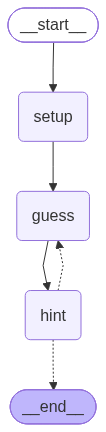

In [7]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
result = app.invoke({})
status = "correct" if result["hint"] == "correct" else "failed"
print(f"Target: {result['target']}, {status} in {result['attempts']} attempt(s), last guess: {result['guess']}")

Target: 10, correct in 1 attempt(s), last guess: 10


In [9]:
for i in range(5):
    r = app.invoke({})
    print(f"Round {i+1}: target={r['target']}, {r['hint']} in {r['attempts']} attempts")

Round 1: target=19, correct in 4 attempts
Round 2: target=2, correct in 3 attempts
Round 3: target=9, correct in 5 attempts
Round 4: target=11, correct in 4 attempts
Round 5: target=14, correct in 5 attempts
